In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stefansaxer/ble-packets-from-tracking-devices")

print("Path to dataset files:", path)

c:\Users\devan\OneDrive\Documents\repos\Bluetooth_recognition_activity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\devan\.cache\kagglehub\datasets\stefansaxer\ble-packets-from-tracking-devices\versions\3


In [39]:
import torch

print(torch.version.cuda)

None



Some useful RF drone data with built in noise

""
,class,class_int,count
0,DJI,0,1280
1,FutabaT14,1,3472
2,FutabaT7,2,801
3,Graupner,3,801
4,Noise,4,8872
5,Taranis,5,1663
6,Turnigy,6,855
""

In [17]:
examplefile = 'IQdata_sample12669_target4_snr24.pt'

sample_id = examplefile.split('_')[1][6:]

snr = examplefile.split('_')[3][-5:].split('.')[0]

target = examplefile.split('_')[2][6:]

print(f"Sample ID: {sample_id}, SNR: {snr}, Target: {target}")

Sample ID: 12669, SNR: 24, Target: 4


In [ ]:
examplefile = 'IQdata_sample12669_target4_snr224.pt'

sample_id = examplefile.split('_')[1][6:]

# snr = examplefile.split('.')[0].split('-')[-1]

target = examplefile.split('_')[2][6:]

print(f"Sample ID: {sample_id}, SNR: {snr}, Target: {target}")

Sample ID: 12669, SNR: IQdata_sample12669_target4_snr224, Target: 4


In [18]:
from torch.utils.data import Dataset
import os
import torch


class DroneRFDataSet(Dataset):
    def __init__(self, data_path, device=None):
        self.data_path = data_path
        self.device = device if device is not None else torch.device("cuda")
        self.files = [f for f in os.listdir(data_path) if f.endswith(".pt") and f.startswith("IQdata")]

        self.samples = []
        self.targets = []
        self.snrs = []

        for file in self.files:
            sample_id = file.split('_')[1][6:]
            target = file.split('_')[2][6:]
            snr = file.split('_')[3][-5:].split('.')[0]

            self.samples.append(sample_id)
            self.targets.append(target)
            self.snrs.append(snr)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        file = self.files[index]

        # get the sample id, target, and snr for the given index
        sample_id = self.samples[index]
        target = self.targets[index]
        snr = self.snrs[index]

        # load data
        data = torch.load(os.path.join(self.data_path, file))

        return sample_id, target, snr, data

In [22]:
device = torch.device("cuda")
rf_dataset = DroneRFDataSet(data_path="../data")

print(len(rf_dataset))

17744


In [32]:
sample_id, target, snr, iq_data = rf_dataset[0]

print(iq_data['x_iq'])

tensor([[ 8.5068e-04, -3.7270e-03, -1.7382e-03,  ...,  9.1976e-01,
          3.2465e+00, -7.9968e-01],
        [-1.4233e-03,  4.8080e-03,  6.0526e-03,  ..., -5.9499e-01,
          1.2086e+00,  2.1661e+00]])


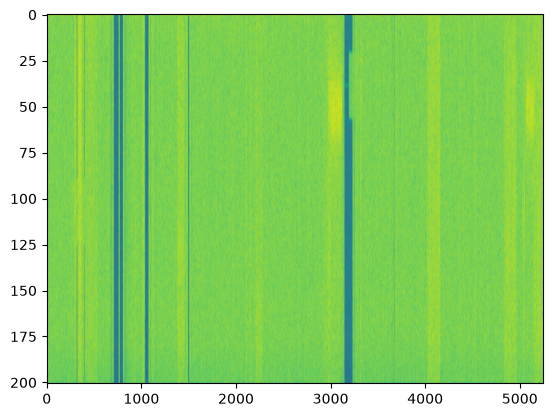

In [38]:
from torchaudio.transforms import Spectrogram
import matplotlib.pyplot as plt

spectrogram_transform = Spectrogram()
iq_spectrogram = spectrogram_transform(iq_data['x_iq'])
plt.imshow(iq_spectrogram.log2()[0,:,:].detach().numpy(), cmap='viridis', aspect='auto')
plt.show()

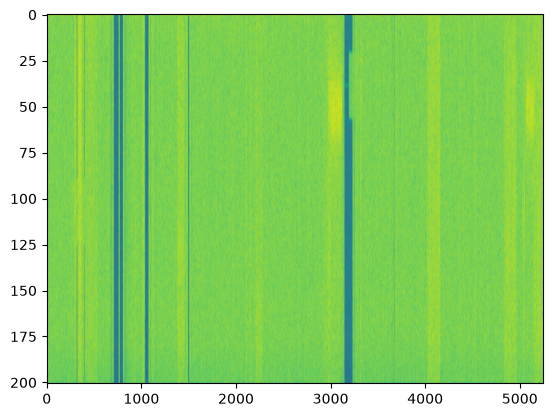

In [ ]:
from torchaudio.transforms import Spectrogram


class SpectrogramTransform:
    def __init__(self):
        self.spectrogram_transform = Spectrogram()

    def __call__(self, iq_data):
        return self.spectrogram_transform(iq_data['x_iq'])

spectrogram_transform = SpectrogramTransform()
iq_spectrogram = spectrogram_transform(iq_data)
plt.imshow(iq_spectrogram.log2()[0,:,:].detach().numpy(), cmap='viridis', aspect='auto')
plt.show()